# Cell Type Annotation

***

In this notebook we perform cell type annotation for the merged liver `AnnData object`. Cell type annotation is the process of assigning biological identities to single cells based on their gene expression profiles.

In [1]:
# ---------------
#     Imports
# ---------------

# Standard imports
from pathlib import Path

# Third-party imports
import anndata as ad
import decoupler as dc
import numpy as np
import pandas as pd
import scanpy as sc

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
save_dir = Path("../output/cell_type_annotation_ST")
save_dir.mkdir(parents=True, exist_ok=True)

print(f"💾 Save results to: '{save_dir}'")

💾 Save results to: '../output/cell_type_annotation_ST'


## Annotation With `CellTypist` - Cycle 1

### What is `CellTypist` (CT)?

CellTypist is a machine-learning-based tool for automated cell type annotation of single-cell RNA sequencing data. It uses a curated reference database and logistic regression models to provide fast and accurate predictions.

*Publication:* [Link](https://doi.org/10.1016/j.cell.2023.11.026)

### Load Data

In [18]:
adata_file = Path("../output/data/ST_data_integration/liver_merged.h5ad")
adata = ad.read_h5ad(adata_file)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances', 'scVI_neighbors_connectivities', 'scVI_neighbors_distances', 'scVI_norm_neighbors_connectivities', 'scVI_norm_neighbors_distances'

In [4]:
backup_file = save_dir / f"unannotated_{adata_file.name}"
adata.write(backup_file, compression="gzip")

### Normalize Data

The online interface for CT requires an `AnnData` object stored in the *h5ad* format.  
To process the the count data it has to **log-normalized** and afterwards **scaled** to 10,000 counts per cell.

&rarr; `scanpy.pp.normalize_total(target_sum=1e4)` and `scanpy.pp.log1p`

[*Source*](https://www.celltypist.org/tutorials/onlineguide#upload-query-data)

In [5]:
adata.X = adata.layers["raw"].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers["CellTypist_normalized"] = adata.X.copy()

In [7]:
save_file = save_dir / f"{adata_file.name}"
adata.write(save_file, compression="gzip")

### Visualize CT Annotation

In [4]:
# Reload data
adata_file = Path("../output/cell_type_annotation_ST/liver_merged.h5ad")
adata = ad.read_h5ad(adata_file)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'CellTypist_normalized', 'log1p', 'raw', 'scVI

In [5]:
prediction_dir = Path("../output/cell_type_annotation_ST/CellTypist_predictions")
predictions = pd.read_csv(prediction_dir / "predicted_labels.csv")

predictions = predictions.set_index(predictions["Unnamed: 0"])
predictions.index.name = None
predictions = predictions[["predicted_labels", "majority_voting"]]

predictions.head()

,predicted_labels,majority_voting
liver1_3_1,Hepatocytes,Endothelial cells
liver1_4_1,Endothelial cells,Hepatocytes
liver1_5_1,Hepatocytes,Hepatocytes
liver1_7_1,Fibroblasts,Fibroblasts
liver1_8_1,Endothelial cells,Endothelial cells


In [6]:
predictions.predicted_labels.unique()

array(['Hepatocytes', 'Endothelial cells', 'Fibroblasts', 'Kupffer cells',
       'Monocytes & Monocyte-derived cells', 'T cells', 'Neutrophils',
       'Basophils', 'Cholangiocytes', 'HsPCs', 'pDCs', 'ILC1s',
       'NK cells', 'cDC2s', 'B cells', 'cDC1s', 'Mig. cDCs'], dtype=object)

In [7]:
predictions.majority_voting.unique()

array(['Endothelial cells', 'Hepatocytes', 'Fibroblasts', 'Kupffer cells'],
      dtype=object)

In [8]:
probabilities = pd.read_csv(prediction_dir / "probability_matrix.csv")
probabilities.head()

,Unnamed: 0,B cells,Basophils,Cholangiocytes,Endothelial cells,Fibroblasts,Hepatocytes,HsPCs,ILC1s,Kupffer cells,Mig. cDCs,Monocytes & Monocyte-derived cells,NK cells,Neutrophils,T cells,cDC1s,cDC2s,pDCs
0,liver1_3_1,0.000460,0.000975,0.001495,0.000051,0.000342,0.591862,0.006646,0.000100,0.028052,0.000392,0.004892,0.000215,0.008867,0.004520,0.000184,0.000074,0.001849
1,liver1_4_1,0.000495,0.004945,0.001144,0.913311,0.010455,0.269643,0.006238,0.000542,0.001007,0.000295,0.001688,0.000152,0.001766,0.012154,0.000052,0.000036,0.005631
2,liver1_5_1,0.000920,0.008361,0.001380,0.324336,0.068875,0.608518,0.007868,0.001841,0.027126,0.003012,0.133218,0.011450,0.000378,0.003447,0.000066,0.000419,0.005240
3,liver1_7_1,0.001317,0.004695,0.001762,0.001283,0.977266,0.619493,0.017362,0.000242,0.232158,0.077236,0.048951,0.003494,0.088655,0.745115,0.020325,0.321156,0.004914
4,liver1_8_1,0.000064,0.000221,0.000068,0.031366,0.000268,0.008929,0.000215,0.000018,0.013225,0.000043,0.000004,0.000018,0.000269,0.000069,0.000003,0.000005,0.000198


In [9]:
probabilities.select_dtypes(float).iloc[0].sum()

0.6509753366435522

In [10]:
probabilities.select_dtypes(float).iloc[30000].sum()

0.0207626953297162

Apparently the predictions vary from cell type to cell type.

In [11]:
confidence = probabilities.select_dtypes(float).max(axis=1)
confidence.head()

0    0.591862
1    0.913311
2    0.608518
3    0.977266
4    0.031366
dtype: float64

In [12]:
adata.obs["CT_predictions"] = predictions["predicted_labels"]
adata.obs["CT_predictions"]

liver1_3_1             Hepatocytes
liver1_4_1       Endothelial cells
liver1_5_1             Hepatocytes
liver1_7_1             Fibroblasts
liver1_8_1       Endothelial cells
                       ...        
liver2_531_45    Endothelial cells
liver2_532_45    Endothelial cells
liver2_533_45        Kupffer cells
liver2_534_45          Hepatocytes
liver2_535_45    Endothelial cells
Name: CT_predictions, Length: 67785, dtype: object

In [13]:
adata.obs["CT_majority"] = predictions["majority_voting"]
adata.obs["CT_majority"]

liver1_3_1       Endothelial cells
liver1_4_1             Hepatocytes
liver1_5_1             Hepatocytes
liver1_7_1             Fibroblasts
liver1_8_1       Endothelial cells
                       ...        
liver2_531_45    Endothelial cells
liver2_532_45    Endothelial cells
liver2_533_45          Fibroblasts
liver2_534_45          Hepatocytes
liver2_535_45    Endothelial cells
Name: CT_majority, Length: 67785, dtype: object

In [14]:
save_file = save_dir / f"{adata_file.name}"
adata.write(save_file, compression="gzip")

In [16]:
ct_predictions = adata.obs[["CT_predictions", "CT_majority"]]

ct_predictions = ct_predictions.copy()
ct_predictions["confidence"] = confidence.values
ct_predictions["confidence_rounded"] = ct_predictions["confidence"].round(decimals=2)

ct_predictions.to_feather(save_dir / "pdata_CT_predictions.feather")
ct_predictions.head()

,CT_predictions,CT_majority,confidence,confidence_rounded
liver1_3_1,Hepatocytes,Endothelial cells,0.591862,0.59
liver1_4_1,Endothelial cells,Hepatocytes,0.913311,0.91
liver1_5_1,Hepatocytes,Hepatocytes,0.608518,0.61
liver1_7_1,Fibroblasts,Fibroblasts,0.977266,0.98
liver1_8_1,Endothelial cells,Endothelial cells,0.031366,0.03


In [4]:
save_file = save_dir / "liver_merged.h5ad"
adata = ad.read_h5ad(save_file, backed=True)
adata

AnnData object with n_obs × n_vars = 67785 × 951 backed at '../output/cell_type_annotation_ST/liver_merged.h5ad'
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 

In [17]:
ct_cluster_predictions = adata.obs.groupby(
    "scVI_leiden",
    observed=True,
)[
    "CT_predictions"
].agg(lambda x: x.value_counts().idxmax())

ct_cluster_predictions = ct_cluster_predictions.reset_index()
ct_cluster_predictions = ct_cluster_predictions.rename(
    columns={
        "scVI_leiden": "cluster",
        "CT_predictions": "celltypist",
    }
)
ct_cluster_predictions.to_feather(save_dir / "pdata_ct_cluster_mapping.feather")

ct_cluster_predictions

,cluster,celltypist
0,0,Endothelial cells
1,1,Endothelial cells
2,2,Endothelial cells
3,3,Hepatocytes
4,4,Endothelial cells
5,5,Endothelial cells
6,6,Kupffer cells
7,7,Fibroblasts
8,8,Endothelial cells
9,9,Endothelial cells


## Manual Annotation

In [2]:
# Reload data
adata_file = Path("../output/cell_type_annotation_ST/liver_merged.h5ad")
adata = ad.read_h5ad(adata_file)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'CellTypist_normalized', 'log1p', 'raw', 'scVI

In [39]:
xml_file = Path("../data/cell_type_annotation/cell_type_mapping.xlsx")
xml = pd.read_excel(xml_file, sheet_name="Annotation")
xml

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,Unnamed: 0,Hepatocytes,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Kupffer cells,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Others,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
0,NaN,Hepatocytes_1,Hepatocytes_2,Hepatocytes_3,Hepatocytes_4,Hepatocytes_5,Kupffer_1,Kupffer_2,Kupffer_3,Kupffer_4,...,T-cells_2,T-cells_3,T-cells_4,Plasma cells,B-cells,Cholangiocytes,Erythroid,NaN,NaN,3
1,Abca2,0,0,0,0,0,0,0,0,0,...,0,3,2,0,0,2,0,NaN,NaN,2
2,Abi1,0,0,0,0,0,3,2,3,2,...,2,2,2,0,2,0,0,NaN,NaN,1
3,Abi2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,2,0,NaN,NaN,0
4,Abl1,2,2,2,2,2,3,0,0,2,...,0,2,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,NegPrb6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
967,NegPrb7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
968,NegPrb8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
969,NegPrb9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


Perform manual changes to the XML to make it usable in the code.

In [40]:
# Drop fist row
# Gets added later as multi-index
xml = xml.iloc[1:]
xml

,Unnamed: 0,Hepatocytes,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Kupffer cells,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Others,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
1,Abca2,0,0,0,0,0,0,0,0,0,...,0,3,2,0,0,2,0,NaN,NaN,2
2,Abi1,0,0,0,0,0,3,2,3,2,...,2,2,2,0,2,0,0,NaN,NaN,1
3,Abi2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,2,0,NaN,NaN,0
4,Abl1,2,2,2,2,2,3,0,0,2,...,0,2,0,0,0,0,0,NaN,NaN,NaN
5,Ace2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,NaN,NaN,non specific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,NegPrb6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
967,NegPrb7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
968,NegPrb8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
969,NegPrb9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [41]:
# Set gene name column as index
xml = xml.rename(columns={"Unnamed: 0": "Genes"})
xml = xml.set_index("Genes")
xml.index.name = None  # Remove index name
xml

,Hepatocytes,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Kupffer cells,Unnamed: 7,Unnamed: 8,Unnamed: 9,LSECs,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Others,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
Abca2,0,0,0,0,0,0,0,0,0,0,...,0,3,2,0,0,2,0,NaN,NaN,2
Abi1,0,0,0,0,0,3,2,3,2,0,...,2,2,2,0,2,0,0,NaN,NaN,1
Abi2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,2,0,NaN,NaN,0
Abl1,2,2,2,2,2,3,0,0,2,3,...,0,2,0,0,0,0,0,NaN,NaN,NaN
Ace2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,NaN,NaN,non specific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NegPrb6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
NegPrb7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
NegPrb8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
NegPrb9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [42]:
# Drop last columns since they hold no information
xml = xml.drop(xml.columns[[20, 21, 22]], axis=1)
xml

,Hepatocytes,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Kupffer cells,Unnamed: 7,Unnamed: 8,Unnamed: 9,LSECs,HSCs,Unnamed: 12,T cells,Unnamed: 14,Unnamed: 15,Unnamed: 16,Others,Unnamed: 18,Unnamed: 19,Unnamed: 20
Abca2,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3,2,0,0,2,0
Abi1,0,0,0,0,0,3,2,3,2,0,0,0,2,2,2,2,0,2,0,0
Abi2,0,0,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,2,2,0
Abl1,2,2,2,2,2,3,0,0,2,3,2,3,0,0,2,0,0,0,0,0
Ace2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NegPrb6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
NegPrb7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
NegPrb8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
NegPrb9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [43]:
# Define the levels of the MultiIndex
categories = ["Hepatocytes", "Kupffer cells", "LSECs", "HSCs", "T cells", "Others"]

subcategories = [
    [
        "Hepatocytes_1",
        "Hepatocytes_2",
        "Hepatocytes_3",
        "Hepatocytes_4",
        "Hepatocytes_5",
    ],
    ["Kupffer_1", "Kupffer_2", "Kupffer_3", "Kupffer_4"],
    ["Endothelial cells"],
    ["Smooth muscle cells", "Fibroblasts"],
    ["T-cells_1", "T-cells_2", "T-cells_3", "T-cells_4"],
    ["Plasma cells", "B-cells", "Cholangiocytes", "Erythroid"],
]

In [44]:
# Create multi-index
multi_index = pd.MultiIndex.from_tuples(
    [
        (category, col)
        for category, cols in zip(categories, subcategories)
        for col in cols
    ]
)

multi_index

MultiIndex([(  'Hepatocytes',       'Hepatocytes_1'),
            (  'Hepatocytes',       'Hepatocytes_2'),
            (  'Hepatocytes',       'Hepatocytes_3'),
            (  'Hepatocytes',       'Hepatocytes_4'),
            (  'Hepatocytes',       'Hepatocytes_5'),
            ('Kupffer cells',           'Kupffer_1'),
            ('Kupffer cells',           'Kupffer_2'),
            ('Kupffer cells',           'Kupffer_3'),
            ('Kupffer cells',           'Kupffer_4'),
            (        'LSECs',   'Endothelial cells'),
            (         'HSCs', 'Smooth muscle cells'),
            (         'HSCs',         'Fibroblasts'),
            (      'T cells',           'T-cells_1'),
            (      'T cells',           'T-cells_2'),
            (      'T cells',           'T-cells_3'),
            (      'T cells',           'T-cells_4'),
            (       'Others',        'Plasma cells'),
            (       'Others',             'B-cells'),
            (       'Others'

In [45]:
# Add inde to xml dataframe
xml.columns = multi_index
xml

Hepatocytes                                            \
         Hepatocytes_1 Hepatocytes_2 Hepatocytes_3 Hepatocytes_4   
Abca2                0             0             0             0   
Abi1                 0             0             0             0   
Abi2                 0             0             0             0   
Abl1                 2             2             2             2   
Ace2                 0             0             0             0   
...                ...           ...           ...           ...   
NegPrb6              0             0             0             0   
NegPrb7              0             0             0             0   
NegPrb8              0             0             0             0   
NegPrb9              0             0             0             0   
NegPrb10             0             0             0             0   

                       Kupffer cells                                \
         Hepatocytes_5     Kupffer_1 Kupffer_2 Kupffer_3 Kupffer_4   
Abca2                0             0         0         0         0   
Abi1                 0             3         2         3         2   
Abi2                 0             0         0         0         0   
Abl1                 2             3         0         0         2   
Ace2                 0             0         0         0         0   
...                ...           ...       ...       ...       ...   
NegPrb6              0             0         0         0         0   
NegPrb7              0             0         0         0         0   
NegPrb8              0             0         0         0         0   
NegPrb9              0             0         0         0         0   
NegPrb10             0             0         0         0         0   

                     LSECs                HSCs               T cells  \
         Endothelial cells Smooth muscle cells Fibroblasts T-cells_1   
Abca2                    0                   0           0         2   
Abi1                     0                   0           0         2   
Abi2                     0                   3           3         0   
Abl1                     3                   2           3         0   
Ace2                     0                   0           0         0   
...                    ...                 ...         ...       ...   
NegPrb6                  0                   0           0         0   
NegPrb7                  0                   0           0         0   
NegPrb8                  0                   0           0         0   
NegPrb9                  0                   0           0         0   
NegPrb10                 0                   0           0         0   

                                             Others                         \
         T-cells_2 T-cells_3 T-cells_4 Plasma cells B-cells Cholangiocytes   
Abca2            0         3         2            0       0              2   
Abi1             2         2         2            0       2              0   
Abi2             0         0         0            0       2              2   
Abl1             0         2         0            0       0              0   
Ace2             0         0         0            0       0              3   
...            ...       ...       ...          ...     ...            ...   
NegPrb6          0         0         0            0       0              0   
NegPrb7          0         0         0            0       0              0   
NegPrb8          0         0         0            0       0              0   
NegPrb9          0         0         0            0       0              0   
NegPrb10         0         0         0            0       0              0   

                    
         Erythroid  
Abca2            0  
Abi1             0  
Abi2             0  
Abl1             0  
Ace2             0  
...            ...  
NegPrb6          0  
NegPrb7          0  
NegPrb8          0  
NegPrb9          0  
NegPrb10   

In [46]:
# Save the data frame so processing has not to be repeated
save_xml_dir = Path("../data/cell_type_annotation/")
xml.to_feather(save_xml_dir / "cell_type_mapping.feather")

#### Identify Marker Genes

**Why use Wilxocon?**  

| Method                   | Assumptions                                   | Pros                                                   | Cons                                                  | When to Use |
|--------------------------|----------------------------------------------|-------------------------------------------------------|------------------------------------------------------|-------------|
| **t-test**               | Assumes normal distribution                 | Fast, easy to interpret                              | Sensitive to outliers, not ideal for count data     | If data is approximately normal, or for quick exploratory analysis |
| **t-test_overestim_var** | Like t-test but adjusts for small sample sizes | More robust for small sample sizes                   | Still assumes normality, less robust than Wilcoxon  | If sample size is small but t-test is still preferred |
| **wilcoxon**             | Non-parametric, does not assume normality   | More robust to outliers, better for non-normal data | Slower for large datasets                           | Best for scRNA-seq data, widely used due to robustness |
| **logreg** (Logistic regression) | Assumes a linear relationship between expression and group label | Can control for covariates, handles imbalanced group sizes well | Computationally intensive, harder to interpret | When adjusting for confounders, or for finding marker genes with a clear separation between groups |


In [8]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'CellTypist_normalized', 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances', 'scVI_neighbors_connectivities', 'scVI_neighbors_distances', 'scVI_norm_neighbors_connectivities', 'scVI_norm_neighbors_distances'

In [10]:
# Use "wilcoxon" to indentify marker genes
sc.tl.rank_genes_groups(
    adata,
    use_raw=False,
    layer="log1p",
    groupby="scVI_leiden",
    method="wilcoxon",
)

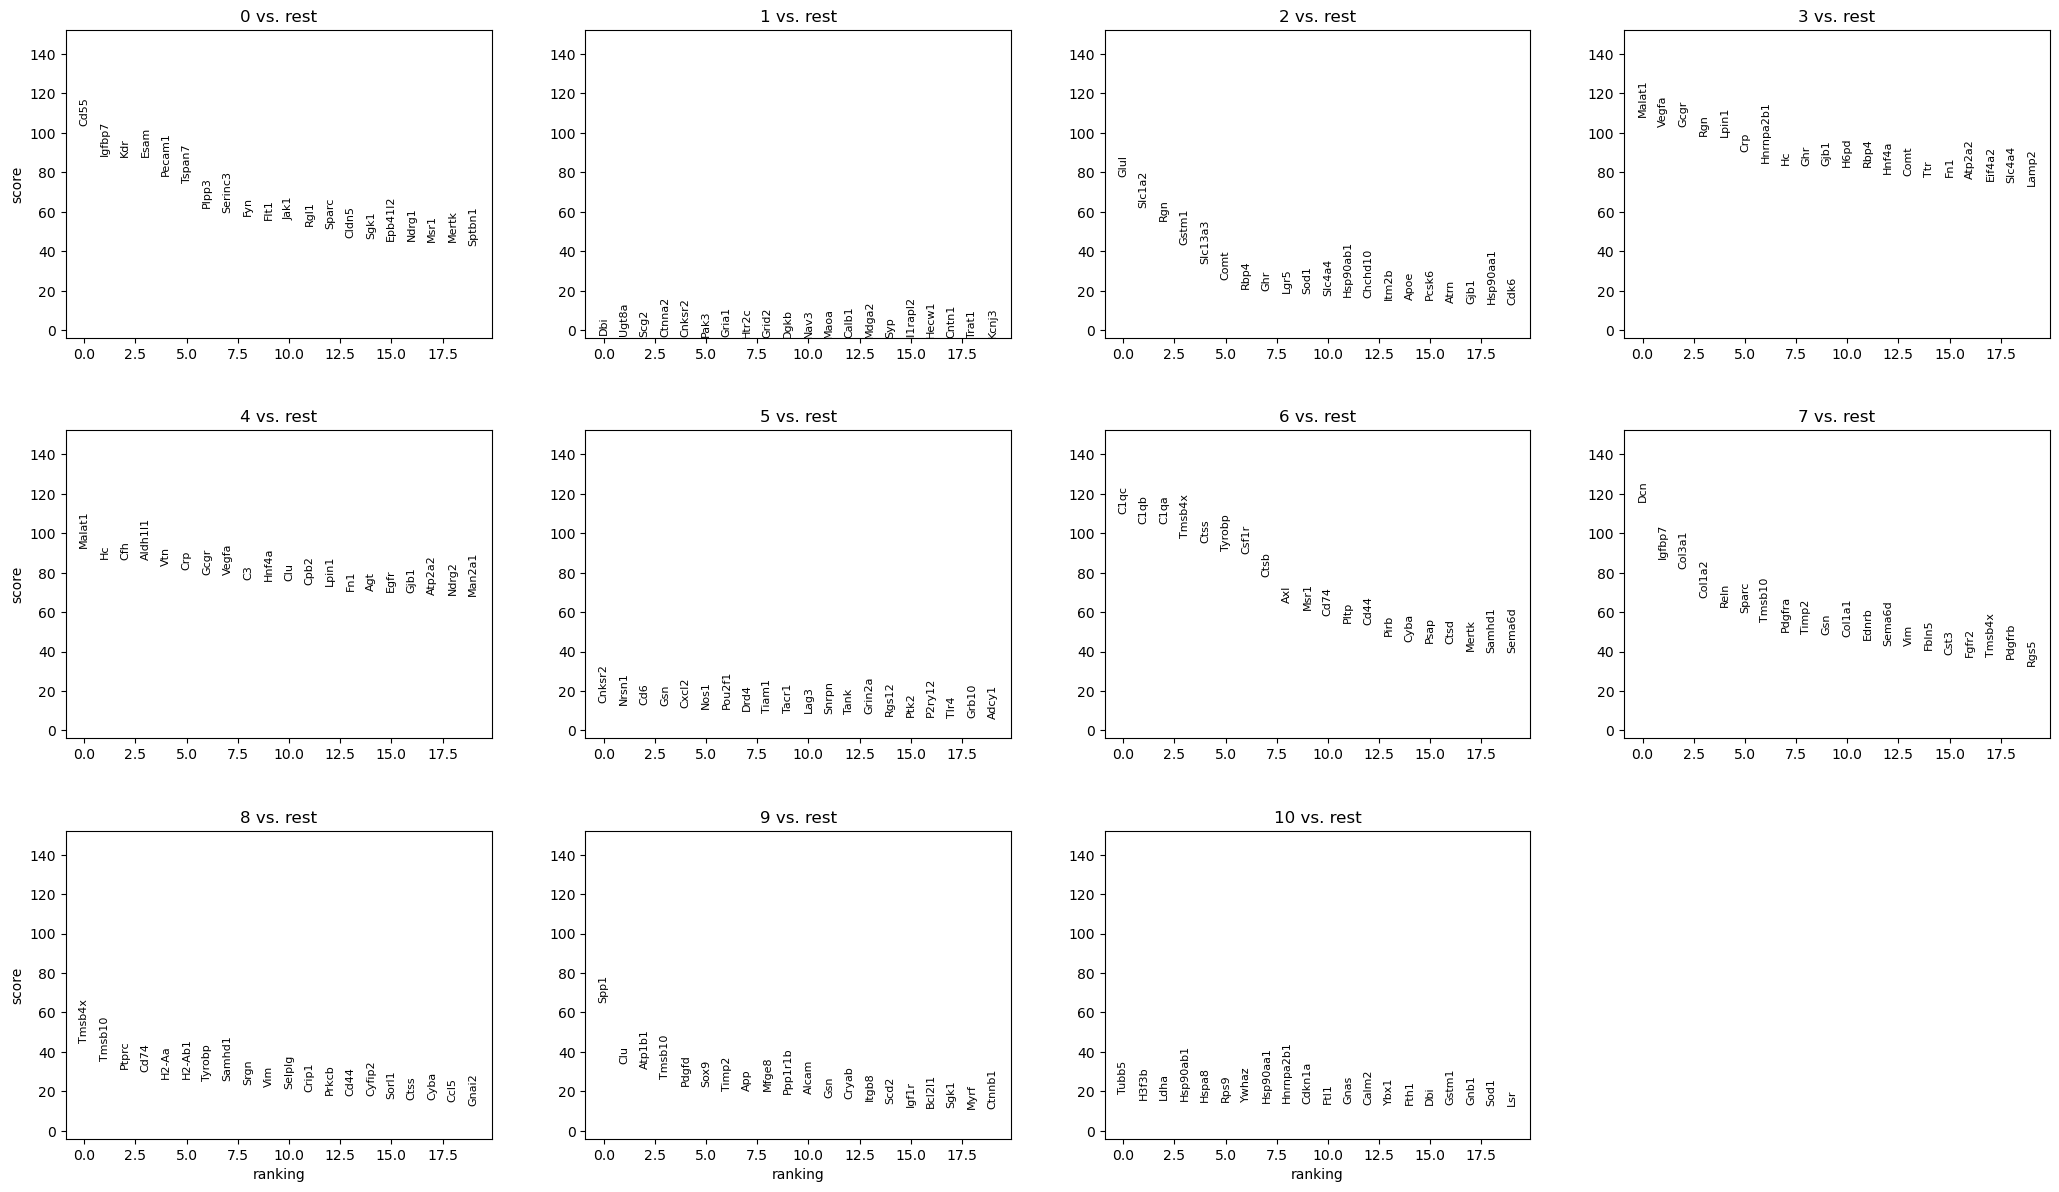

In [6]:
sc.pl.rank_genes_groups(adata)

In [13]:
gene_ranks = sc.get.rank_genes_groups_df(adata, group=None)
gene_ranks.to_feather(save_dir / "pdata_gene_ranks.feather")

In [15]:
# Convert to pandas DataFrame
marker_genes = pd.DataFrame(
    {
        group: adata.uns["rank_genes_groups"]["names"][group]
        for group in adata.obs["scVI_leiden"].cat.categories
    }
)

marker_genes.to_feather(save_dir / "pdata_marker_genes.feather")
marker_genes.head()

,0,1,2,3,4,5,6,7,8,9,10
0,Cd55,Dbi,Glul,Malat1,Malat1,Cnksr2,C1qc,Dcn,Tmsb4x,Spp1,Tubb5
1,Igfbp7,Ugt8a,Slc1a2,Vegfa,Hc,Nrsn1,C1qb,Igfbp7,Tmsb10,Clu,H3f3b
2,Kdr,Scg2,Rgn,Gcgr,Cfh,Cd6,C1qa,Col3a1,Ptprc,Atp1b1,Ldha
3,Esam,Ctnna2,Gstm1,Rgn,Aldh1l1,Gsn,Tmsb4x,Col1a2,Cd74,Tmsb10,Hsp90ab1
4,Pecam1,Cnksr2,Slc13a3,Lpin1,Vtn,Cxcl2,Ctss,Reln,H2-Aa,Pdgfd,Hspa8


#### Annotate Cell Types

In [8]:
# Constants for cell type visualization
DEFAULT_CELL_TYPE_COLORS = [
    "#1D2951",  # Space Cadet (dark blue)
    "#FFD166",  # Warm Yellow
    "#4BA3C3",  # Sky Blue
    "#F25C54",  # Coral Red
    "#007C91",  # Deep Teal
    "#EF798A",  # Dusty Rose
    "#6DCDB8",  # Mint Green
    "#FF9F1C",  # Vivid Orange
    "#6B4C9A",  # Violet Indigo
    "#A4C400",  # Lime Green
    "#8E7DBE",  # Lavender Purple
    "#2E8B57",  # Sea Green
]


def annotate_manually(
    adata: ad.AnnData,
    markers: pd.DataFrame,
    mapping: pd.DataFrame,
    group_col: str,
) -> ad.AnnData:
    """Annotate cell clusters with cell types based on marker gene expression.

    This function performs manual cell type annotation by comparing marker gene
    expression patterns against a reference mapping. For each cluster, it calculates
    the proportion of marker genes expressed and assigns the cell type with the
    highest proportion score.

    :param adata: Annotated data object containing single-cell data
    :type adata: ad.AnnData
    :param markers: DataFrame where each column represents a cluster and contains
                   marker gene identifiers for that cluster
    :type markers: pd.DataFrame
    :param mapping: Reference mapping DataFrame containing cell type information.
                   Should be indexed by marker gene identifiers. Expected to have
                   MultiIndex or tuple-like column structure where second element
                   contains cell type names
    :type mapping: pd.DataFrame
    :param group_col: Column name in adata.obs that contains cluster assignments
    :type group_col: str

    :return: The input AnnData object with added 'manual_annotation' column in obs
    :rtype: ad.AnnData
    """
    annotation = {}

    # Process each cluster to determine cell type annotation
    for col in markers.columns:
        # Get marker subset for current cluster
        marker_subset = mapping.loc[markers[col]]

        # Calculate cell type scores by comparing marker expression proportions
        cell_type = (marker_subset.sum() / mapping.sum()).idxmax()

        # Extract cell type name (assumes cell_type is tuple-like with name at index 1)
        annotation[col] = cell_type[1]

    print(annotation)

    # Add manual annotation column to observations
    obs_name = f"manual_prediction_top{len(markers)}"
    adata.obs[obs_name] = [annotation[clust] for clust in adata.obs[group_col]]

    # Create UMAP visualization with cell type annotations
    sc.pl.umap(
        adata,
        color=obs_name,
        palette=DEFAULT_CELL_TYPE_COLORS,
        legend_loc="on data",
        show=True,
    )

    return adata

In [9]:
adata.obsm["X_umap"] = adata.obsm["scVI_umap"]

{'0': 'Fibroblasts', '1': 'Hepatocytes_3', '2': 'Hepatocytes_3', '3': 'Hepatocytes_3', '4': 'Hepatocytes_5', '5': 'T-cells_3', '6': 'Kupffer_1', '7': 'Fibroblasts', '8': 'Kupffer_3', '9': 'Cholangiocytes', '10': 'Erythroid'}


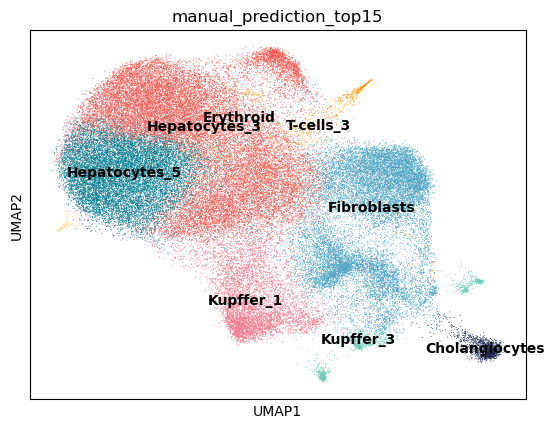

In [10]:
top_n = marker_genes.head(15)
adata = annotate_manually(adata, top_n, xml, "scVI_leiden")

{'0': 'Fibroblasts', '1': 'Cholangiocytes', '2': 'Hepatocytes_3', '3': 'Hepatocytes_3', '4': 'Hepatocytes_2', '5': 'T-cells_3', '6': 'Kupffer_1', '7': 'Smooth muscle cells', '8': 'Kupffer_3', '9': 'Cholangiocytes', '10': 'Plasma cells'}


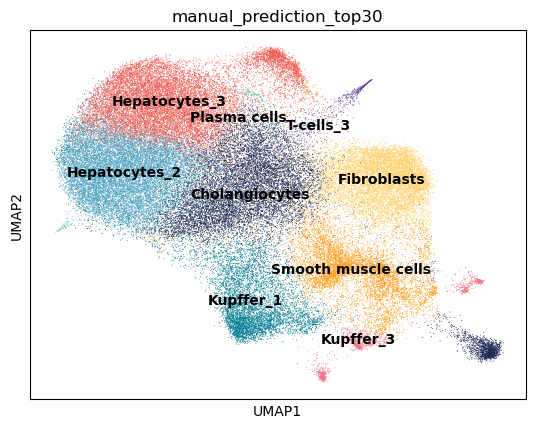

In [12]:
top_n = marker_genes.head(30)
adata = annotate_manually(adata, top_n, xml, "scVI_leiden")

In [13]:
save_file = save_dir / f"{adata_file.name}"
adata.write(save_file, compression="gzip")

In [19]:
ct_cluster_map = pd.read_feather(save_dir / "pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist
0,0,Endothelial cells
1,1,Endothelial cells
2,2,Endothelial cells
3,3,Hepatocytes
4,4,Endothelial cells
5,5,Endothelial cells
6,6,Kupffer cells
7,7,Fibroblasts
8,8,Endothelial cells
9,9,Endothelial cells


In [27]:
manual_map_t15 = adata.obs.groupby(
    "scVI_leiden",
    observed=True,
)[
    "manual_prediction_top15"
].agg(lambda x: x.value_counts().idxmax())

manual_map_t15 = manual_map_t15.reset_index()
manual_map_t15

,scVI_leiden,manual_prediction_top15
0,0,Fibroblasts
1,1,Hepatocytes_3
2,2,Hepatocytes_3
3,3,Hepatocytes_3
4,4,Hepatocytes_5
5,5,T-cells_3
6,6,Kupffer_1
7,7,Fibroblasts
8,8,Kupffer_3
9,9,Cholangiocytes


In [26]:
manual_map_t30 = adata.obs.groupby(
    "scVI_leiden",
    observed=True,
)[
    "manual_prediction_top30"
].agg(lambda x: x.value_counts().idxmax())

manual_map_t30 = manual_map_t30.reset_index()

In [31]:
ct_cluster_map["manual_t15"] = manual_map_t15["manual_prediction_top15"]
ct_cluster_map["manual_t30"] = manual_map_t30["manual_prediction_top30"]

ct_cluster_map.to_feather(save_dir / "pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist,manual_t15,manual_t30
0,0,Endothelial cells,Fibroblasts,Fibroblasts
1,1,Endothelial cells,Hepatocytes_3,Cholangiocytes
2,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3
3,3,Hepatocytes,Hepatocytes_3,Hepatocytes_3
4,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2
5,5,Endothelial cells,T-cells_3,T-cells_3
6,6,Kupffer cells,Kupffer_1,Kupffer_1
7,7,Fibroblasts,Fibroblasts,Smooth muscle cells
8,8,Endothelial cells,Kupffer_3,Kupffer_3
9,9,Endothelial cells,Cholangiocytes,Cholangiocytes


## Annotation With `DecoupleR`

In [ ]:
# Reload data
adata_file = Path("../output/cell_type_annotation_ST/liver_merged.h5ad")
adata = ad.read_h5ad(adata_file)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'CellTypist_normalized', 'log1p', 'raw', 'scVI

In [19]:
markers = dc.get_resource(name="PanglaoDB", organism="mouse", license="academic")
markers.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
0,Ctrb1,False,Enterocytes,Endoderm,True,0.0,0.004394,True,0.003311,0.020480,9606,GI tract,0.017
1,Ctrb1,True,Acinar cells,Endoderm,True,1.0,0.000629,True,0.957143,0.015920,9606,Pancreas,0.017
2,Klk1,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
3,Klk1b21,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013
4,Klk1b1,True,Endothelial cells,Mesoderm,True,0.0,0.008420,True,0.000000,0.014915,9606,Vasculature,0.013


In [20]:
len(markers)

8206

#### Filter Markers

In [27]:
occuring = markers[markers["genesymbol"].str.upper().isin(adata.var_names.str.upper())]
occuring.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
251,Egfr,False,Adipocyte progenitor cells,Mesoderm,True,0.0,0.022243,True,0.0,0.012769,9606,Connective tissue,0.014
252,Egfr,True,Adipocytes,Mesoderm,True,0.0,0.022292,True,0.0,0.012775,9606,Connective tissue,0.014
253,Egfr,True,Bergmann glia,Ectoderm,True,0.0,0.022243,True,0.0,0.012771,9606,Brain,0.014
254,Egfr,True,Neuroblasts,Ectoderm,True,0.0,0.022243,True,0.0,0.012769,9606,Brain,0.014
255,Egfr,True,Gastric chief cells,Endoderm,True,0.0,0.022243,True,0.0,0.012769,9606,GI tract,0.014


In [28]:
len(occuring)

1000

**1000** entries with markers from the spatial transcriptomics dataset.

In [29]:
occuring["genesymbol"].unique()

<StringArray>
[  'Egfr',    'Lep',   'Mc2r',   'Tlr4',  'Adrb2',   'Mmp2',   'Maob',
   'H6pd', 'Deptor',     'C3',
 ...
  'Fbln5',  'Kat2b',   'Wwp2',   'Cd3d',    'Cd6',   'Cd81',   'Il10',
   'Il22',  'Nr3c1',  'Itgb8']
Length: 371, dtype: string

**371** unique marker entries.

In [31]:
filtered = markers[markers["mouse"].astype(bool) & (markers["organ"] == "Liver")]
filtered = filtered[
    filtered["genesymbol"].str.upper().isin(adata.var_names.str.upper())
]
filtered.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
353,Tlr4,True,Kupffer cells,Mesoderm,True,0.000000,0.000313,True,0.00000,0.000000,9606,Liver,0.000
718,Acta2,True,Hepatic stellate cells,Endoderm,True,0.500000,0.019122,True,0.00000,0.038888,9606,Liver,0.035
737,Ttr,True,Hepatocytes,Endoderm,True,0.594595,0.067195,True,0.00000,0.000000,9606,Liver,0.055
886,Il1b,False,Kupffer cells,Mesoderm,True,0.000000,0.025376,True,0.21875,0.027326,9606,Liver,0.027
1051,Gfap,False,Hepatic stellate cells,Endoderm,True,0.000000,0.005643,True,0.50000,0.014888,9606,Liver,0.013


In [32]:
len(filtered)

37

In [33]:
filtered.cell_type.unique()

['Kupffer cells', 'Hepatic stellate cells', 'Hepatocytes', 'Cholangiocytes', 'Hepatoblasts']
Categories (178, string): [Acinar cells, Adipocyte progenitor cells, Adipocytes, Adrenergic neurons, ..., Tuft cells, Undefined placental cells, Urothelial cells, Vascular smooth muscle cells]

In [34]:
# Deduplicate markers
deduplicated = filtered[~filtered.duplicated(["cell_type", "genesymbol"])]
deduplicated.to_feather(save_dir / "deduplicated_pdb_markers.feather")
deduplicated.head()

,genesymbol,canonical_marker,cell_type,germ_layer,human,human_sensitivity,human_specificity,mouse,mouse_sensitivity,mouse_specificity,ncbi_tax_id,organ,ubiquitiousness
353,Tlr4,True,Kupffer cells,Mesoderm,True,0.000000,0.000313,True,0.00000,0.000000,9606,Liver,0.000
718,Acta2,True,Hepatic stellate cells,Endoderm,True,0.500000,0.019122,True,0.00000,0.038888,9606,Liver,0.035
737,Ttr,True,Hepatocytes,Endoderm,True,0.594595,0.067195,True,0.00000,0.000000,9606,Liver,0.055
886,Il1b,False,Kupffer cells,Mesoderm,True,0.000000,0.025376,True,0.21875,0.027326,9606,Liver,0.027
1051,Gfap,False,Hepatic stellate cells,Endoderm,True,0.000000,0.005643,True,0.50000,0.014888,9606,Liver,0.013


In [35]:
len(deduplicated)

37

In [38]:
deduplicated = deduplicated[["cell_type", "genesymbol"]]
deduplicated.head()

,cell_type,genesymbol
353,Kupffer cells,Tlr4
718,Hepatic stellate cells,Acta2
737,Hepatocytes,Ttr
886,Kupffer cells,Il1b
1051,Hepatic stellate cells,Gfap


#### Over Representation Analysis (ORA)

In [39]:
dc.run_ora(
    mat=adata,
    net=deduplicated,
    source="cell_type",
    target="genesymbol",
    min_n=1,
    verbose=True,
    use_raw=False,
)

Running ora on mat with 67785 samples and 951 targets for 5 sources.


100%|██████████| 67785/67785 [00:24<00:00, 2817.66it/s]


In [40]:
adata.obsm["ora_estimate"].head()

source,Cholangiocytes,Hepatic stellate cells,Hepatoblasts,Hepatocytes,Kupffer cells
liver1_3_1,-0.0,1.450830,-0.0,3.929811,-0.000000
liver1_4_1,-0.0,-0.000000,-0.0,3.929811,-0.000000
liver1_5_1,-0.0,-0.000000,-0.0,3.929811,-0.000000
liver1_7_1,-0.0,3.236166,-0.0,3.929811,1.669626
liver1_8_1,-0.0,-0.000000,-0.0,3.929811,-0.000000


#### Cell Type Annotation

In [41]:
acts = dc.get_acts(adata, obsm_key="ora_estimate")

# We need to remove inf and set them to the maximum value observed for pvals=0
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

acts

AnnData object with n_obs × n_vars = 67785 × 5
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels', 'scVI_leiden', 'scVI_norm_leiden', 'CT_predictions', 'CT_majority', 'PDB_predictions', 'manual_prediction_top15', 'manual_prediction_top30'
    uns: 'PDB_predictions_colors', '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'manual_prediction_top15_colors', 'manual_prediction_top30_colors', 'neighbors', 'pca', 'rank_genes_groups', 'scVI_leiden', 'scVI_neighbors', 'scVI_norm_leiden', 'scVI_norm_neighbors', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'ora_estimate', 'ora_pvals', 'scVI_norm_pca', 'scVI_norm_umap', 'scVI_umap'

In [42]:
annotations = dc.rank_sources_groups(
    acts, groupby="scVI_leiden", reference="rest", method="wilcoxon"
)
annotations.head()

,group,reference,names,statistic,meanchange,pvals,pvals_adj
0,0,rest,Hepatic stellate cells,9.387278,-0.228049,6.157074e-21,1.026179e-20
1,0,rest,Kupffer cells,0.578541,-0.227870,5.628989e-01,5.628989e-01
2,0,rest,Cholangiocytes,-1.285140,-0.017419,1.987432e-01,2.484290e-01
3,0,rest,Hepatoblasts,-31.707688,-0.473170,1.217307e-220,3.043268e-220
4,0,rest,Hepatocytes,-34.088811,-0.733084,1.080550e-254,5.402752e-254


In [43]:
n_cell_types = 2
ct_dict = (
    annotations.groupby("group")
    .head(n_cell_types)
    .groupby("group")["names"]
    .apply(lambda x: list(x))
    .to_dict()
)
ct_dict

{'0': ['Hepatic stellate cells', 'Kupffer cells'],
 '1': ['Cholangiocytes', 'Hepatoblasts'],
 '10': ['Hepatoblasts', 'Cholangiocytes'],
 '2': ['Hepatocytes', 'Cholangiocytes'],
 '3': ['Hepatocytes', 'Hepatoblasts'],
 '4': ['Hepatoblasts', 'Hepatocytes'],
 '5': ['Cholangiocytes', 'Kupffer cells'],
 '6': ['Kupffer cells', 'Cholangiocytes'],
 '7': ['Hepatic stellate cells', 'Kupffer cells'],
 '8': ['Kupffer cells', 'Hepatic stellate cells'],
 '9': ['Cholangiocytes', 'Hepatic stellate cells']}

In [44]:
annotation_dict = (
    annotations.groupby("group").head(1).set_index("group")["names"].to_dict()
)
annotation_dict

{'0': 'Hepatic stellate cells',
 '1': 'Cholangiocytes',
 '10': 'Hepatoblasts',
 '2': 'Hepatocytes',
 '3': 'Hepatocytes',
 '4': 'Hepatoblasts',
 '5': 'Cholangiocytes',
 '6': 'Kupffer cells',
 '7': 'Hepatic stellate cells',
 '8': 'Kupffer cells',
 '9': 'Cholangiocytes'}

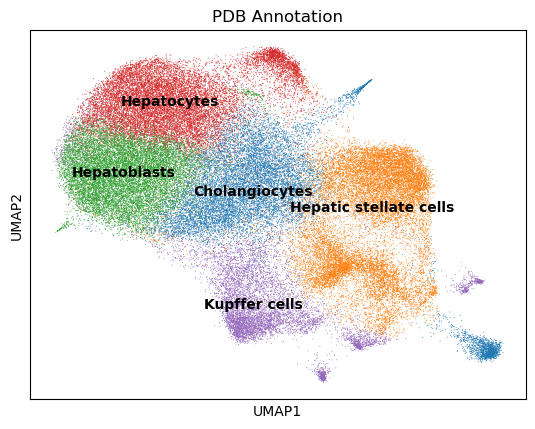

In [45]:
# Add cell type column based on annotation
adata.obs["PDB_predictions"] = [
    annotation_dict[clust] for clust in adata.obs["scVI_leiden"]
]

# Visualize
sc.pl.umap(
    adata,
    color="PDB_predictions",
    title="PDB Annotation",
    legend_loc="on data",
)

In [46]:
save_file = save_dir / f"{adata_file.name}"
adata.write(save_file, compression="gzip")

In [32]:
ct_cluster_map = pd.read_feather(save_dir / "pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist,manual_t15,manual_t30
0,0,Endothelial cells,Fibroblasts,Fibroblasts
1,1,Endothelial cells,Hepatocytes_3,Cholangiocytes
2,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3
3,3,Hepatocytes,Hepatocytes_3,Hepatocytes_3
4,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2
5,5,Endothelial cells,T-cells_3,T-cells_3
6,6,Kupffer cells,Kupffer_1,Kupffer_1
7,7,Fibroblasts,Fibroblasts,Smooth muscle cells
8,8,Endothelial cells,Kupffer_3,Kupffer_3
9,9,Endothelial cells,Cholangiocytes,Cholangiocytes


In [35]:
pdb_map = adata.obs.groupby(
    "scVI_leiden",
    observed=True,
)[
    "PDB_predictions"
].agg(lambda x: x.value_counts().idxmax())

pdb_map = pdb_map.reset_index()
pdb_map

,scVI_leiden,PDB_predictions
0,0,Hepatic stellate cells
1,1,Cholangiocytes
2,2,Hepatocytes
3,3,Hepatocytes
4,4,Hepatoblasts
5,5,Cholangiocytes
6,6,Kupffer cells
7,7,Hepatic stellate cells
8,8,Kupffer cells
9,9,Cholangiocytes


In [36]:
ct_cluster_map["panglaodb"] = pdb_map["PDB_predictions"]

ct_cluster_map.to_feather(save_dir / "pdata_ct_cluster_mapping.feather")
ct_cluster_map

,cluster,celltypist,manual_t15,manual_t30,panglaodb
0,0,Endothelial cells,Fibroblasts,Fibroblasts,Hepatic stellate cells
1,1,Endothelial cells,Hepatocytes_3,Cholangiocytes,Cholangiocytes
2,2,Endothelial cells,Hepatocytes_3,Hepatocytes_3,Hepatocytes
3,3,Hepatocytes,Hepatocytes_3,Hepatocytes_3,Hepatocytes
4,4,Endothelial cells,Hepatocytes_5,Hepatocytes_2,Hepatoblasts
5,5,Endothelial cells,T-cells_3,T-cells_3,Cholangiocytes
6,6,Kupffer cells,Kupffer_1,Kupffer_1,Kupffer cells
7,7,Fibroblasts,Fibroblasts,Smooth muscle cells,Hepatic stellate cells
8,8,Endothelial cells,Kupffer_3,Kupffer_3,Kupffer cells
9,9,Endothelial cells,Cholangiocytes,Cholangiocytes,Cholangiocytes
